In [1]:
import stackview
from cellpose import models, io
import numpy as np
from skimage.data import human_mitosis

In [2]:
import skimage as ski
print(ski.__version__)

0.26.0


[[ 8  8  8 ... 63 78 75]
 [ 8  8  7 ... 67 71 71]
 [ 9  8  8 ... 53 64 66]
 ...
 [ 8  9  8 ... 17 24 59]
 [ 8  8  8 ... 17 22 55]
 [ 8  8  8 ... 16 18 38]]
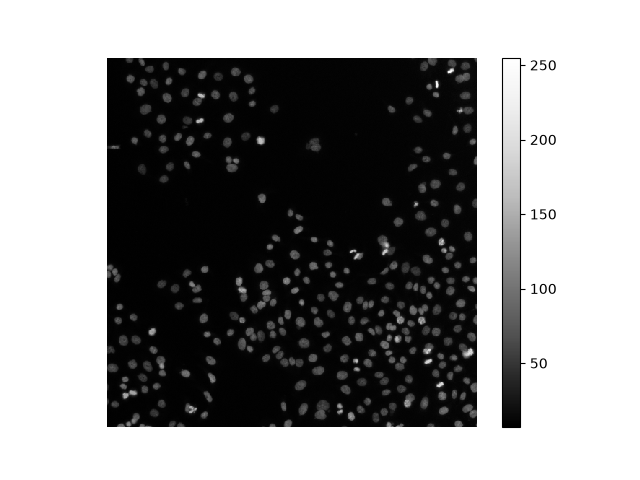
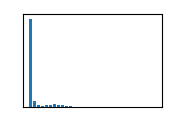

In [3]:
image = human_mitosis()
stackview.insight(image)

In [9]:
model = models.CellposeModel(
    gpu=False,
    model_type="nuclei"
)

In [11]:
channels = [0,0] # This means we are processing single-channel greyscale images.

masks, flows, styles = model.eval(image, diameter=None, channels=channels)

In [14]:
masks

array([[0, 0, 0, ..., 4, 4, 0],
       [0, 0, 0, ..., 4, 4, 4],
       [0, 0, 0, ..., 4, 4, 4],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(512, 512), dtype=uint16)

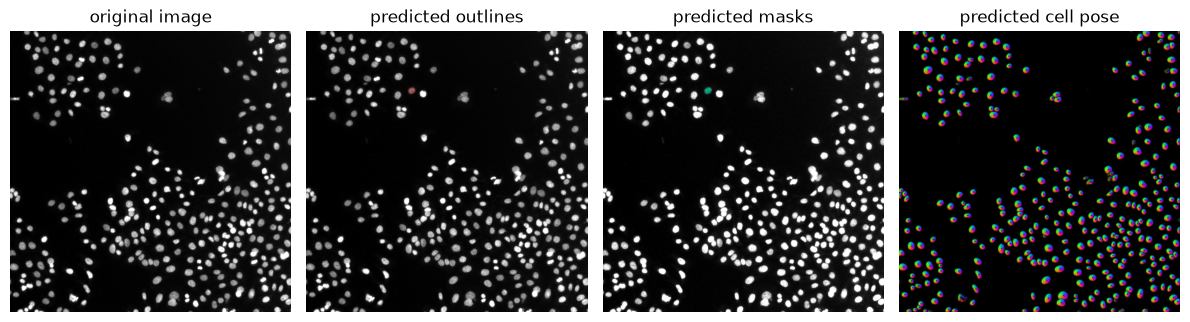

In [19]:
cell_id = 50

single_cell_mask = np.where(masks == cell_id, cell_id, 0)
single_cell_mask
from cellpose import plot
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, image, single_cell_mask, flows[0], channels=channels)
plt.tight_layout()
plt.show()

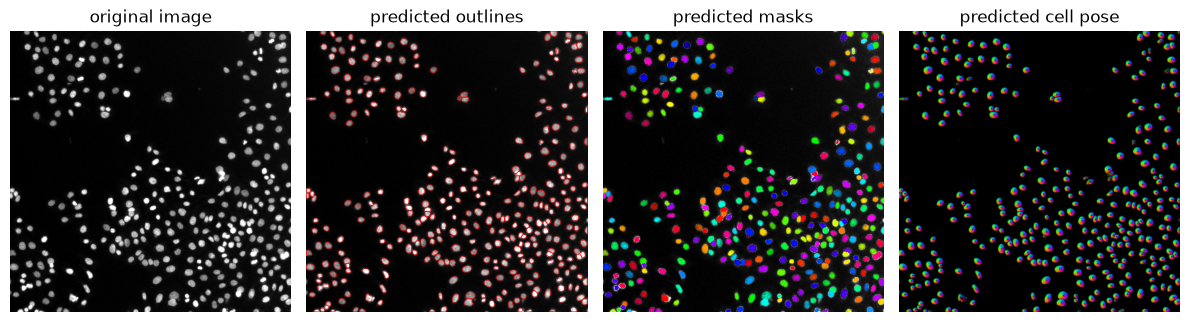

In [12]:
from cellpose import plot
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, image, masks, flows[0], channels=channels)
plt.tight_layout()
plt.show()